# Human-AI Trust Calibration Analysis

> **Humanlike AI Systems and Trust Attribution** — GSoC 2026 / ISSR / University of Alabama

This notebook analyzes behavioral trust data from a controlled experiment where participants make Accept/Override decisions on AI recommendations. The AI's interface cues (name, tone, confidence framing) are systematically manipulated across 8 experimental conditions in a 2×2×2 factorial design.

**Key Research Questions:**
1. Can users distinguish correct from incorrect AI recommendations? (Trust Calibration)
2. Do humanlike interface cues (name, tone, confidence) alter trust behavior?
3. Does decision latency reveal deliberation patterns?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# ── Style Configuration
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'text.color': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#21262d',
    'grid.alpha': 0.6,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.titlesize': 16,
    'figure.titleweight': 'bold',
    'figure.dpi': 120,
})

# Color palette
COLORS = {
    'accept': '#3fb950',
    'override': '#f85149',
    'primary': '#58a6ff',
    'secondary': '#bc8cff',
    'warning': '#d29922',
    'muted': '#8b949e',
    'bg_card': '#1c2128',
    'good': '#3fb950',
    'bad': '#f85149',
    'neutral': '#58a6ff',
}

print('Setup complete')

Setup complete


---
## 1. Data Loading & Preparation

In [2]:
# Load experiment data
df = pd.read_csv('../data/sample_results.csv')

# Type conversions
df['latency_ms'] = pd.to_numeric(df['latency_ms'], errors='coerce')
df['confidence_score'] = pd.to_numeric(df['confidence_score'], errors='coerce')

# Derived columns
df['ai_is_correct'] = df['ai_recommendation'] == df['correct_answer']
df['user_agreed_with_ai'] = df['decision'] == df['ai_recommendation']
df['user_was_correct'] = df['decision'] == df['correct_answer']
df['latency_sec'] = df['latency_ms'] / 1000

# Condition labels
df['condition_label'] = (
    df['agent_name'] + ' / ' + df['tone_style'] + ' / ' + df['confidence_framing']
)

print(f'Loaded {len(df)} records across {df["condition_id"].nunique()} conditions')
print(f'Participants: {df["participant_id"].nunique()}')
print(f'AI Correct: {df["ai_is_correct"].sum()} / {len(df)} ({df["ai_is_correct"].mean()*100:.1f}%)')
df.head()

Loaded 32 records across 8 conditions
Participants: 32
AI Correct: 28 / 32 (87.5%)


,participant_id,condition_id,agent_name,tone_style,confidence_framing,ai_recommendation,scenario_id,correct_answer,confidence_score,decision,latency_ms,timestamp,ai_is_correct,user_agreed_with_ai,user_was_correct,latency_sec,condition_label
0,abc12345,1,System-X,Technical,Probabilistic,Reject,1,Reject,73,Accept,2341.5,2026-02-23T06:00:00Z,True,False,False,2.3415,System-X / Technical / Probabilistic
1,def67890,2,System-X,Technical,Authoritative,Accept,2,Accept,94,Accept,1876.3,2026-02-23T06:01:00Z,True,True,True,1.8763,System-X / Technical / Authoritative
2,ghi11111,3,System-X,Empathetic,Probabilistic,Accept,3,Reject,73,Override,3102.8,2026-02-23T06:02:00Z,False,False,False,3.1028,System-X / Empathetic / Probabilistic
3,jkl22222,4,System-X,Empathetic,Authoritative,Accept,4,Accept,94,Accept,1543.2,2026-02-23T06:03:00Z,True,True,True,1.5432,System-X / Empathetic / Authoritative
4,mno33333,5,Sarah,Technical,Probabilistic,Accept,2,Accept,73,Accept,2789.1,2026-02-23T06:04:00Z,True,True,True,2.7891,Sarah / Technical / Probabilistic


---
## 2. Overall Trust Metrics

The core question: **How well do users calibrate their trust in AI?**

- **Appropriate Reliance** = Accept when AI is correct (good)
- **Over-reliance** = Accept when AI is wrong (dangerous)
- **Trust Discrimination Ratio** = Appropriate ÷ Over-reliance (>1 = calibrated)

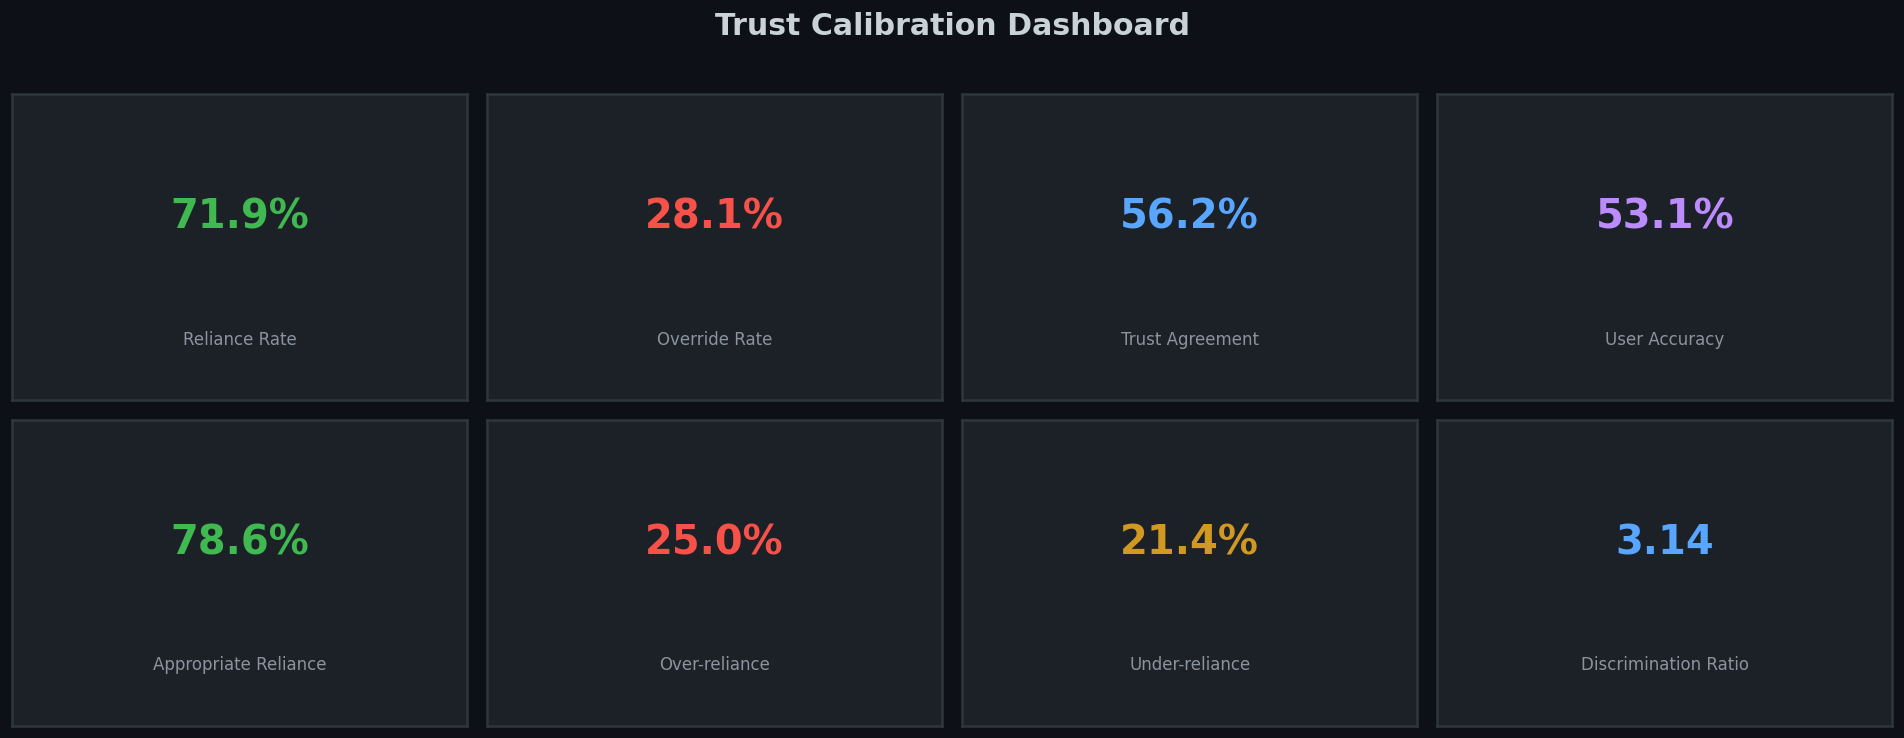

In [3]:
# Compute core metrics
total = len(df)
accepts = (df['decision'] == 'Accept').sum()
overrides = (df['decision'] == 'Override').sum()

ai_correct = df[df['ai_is_correct'] == True]
ai_wrong = df[df['ai_is_correct'] == False]

appropriate_reliance = (ai_correct['decision'] == 'Accept').sum() / len(ai_correct) * 100
under_reliance = (ai_correct['decision'] == 'Override').sum() / len(ai_correct) * 100
over_reliance = (ai_wrong['decision'] == 'Accept').sum() / len(ai_wrong) * 100
appropriate_override = (ai_wrong['decision'] == 'Override').sum() / len(ai_wrong) * 100
trust_discrimination = appropriate_reliance / over_reliance if over_reliance > 0 else float('inf')
user_accuracy = df['user_was_correct'].sum() / total * 100
trust_agreement = df['user_agreed_with_ai'].sum() / total * 100

# Display as a metrics dashboard
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle('Trust Calibration Dashboard', fontsize=18, fontweight='bold', y=1.02)

metrics_data = [
    ('Reliance Rate', f'{accepts/total*100:.1f}%', COLORS['accept']),
    ('Override Rate', f'{overrides/total*100:.1f}%', COLORS['override']),
    ('Trust Agreement', f'{trust_agreement:.1f}%', COLORS['primary']),
    ('User Accuracy', f'{user_accuracy:.1f}%', COLORS['secondary']),
    ('Appropriate Reliance', f'{appropriate_reliance:.1f}%', COLORS['good']),
    ('Over-reliance', f'{over_reliance:.1f}%', COLORS['bad']),
    ('Under-reliance', f'{under_reliance:.1f}%', COLORS['warning']),
    ('Discrimination Ratio', f'{trust_discrimination:.2f}', COLORS['primary']),
]

for ax, (label, value, color) in zip(axes.flat, metrics_data):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.text(0.5, 0.6, value, ha='center', va='center', fontsize=24, fontweight='bold', color=color)
    ax.text(0.5, 0.2, label, ha='center', va='center', fontsize=10, color=COLORS['muted'])
    ax.set_facecolor(COLORS['bg_card'])
    for spine in ax.spines.values():
        spine.set_color('#30363d')
        spine.set_linewidth(1.5)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

---
## 3. Trust Calibration: Correct vs. Incorrect AI

This is the **most important visualization** for trust research. It answers:
> *Do users behave differently when the AI is correct vs. when it's wrong?*

Well-calibrated users should **accept correct AI** and **override incorrect AI**.

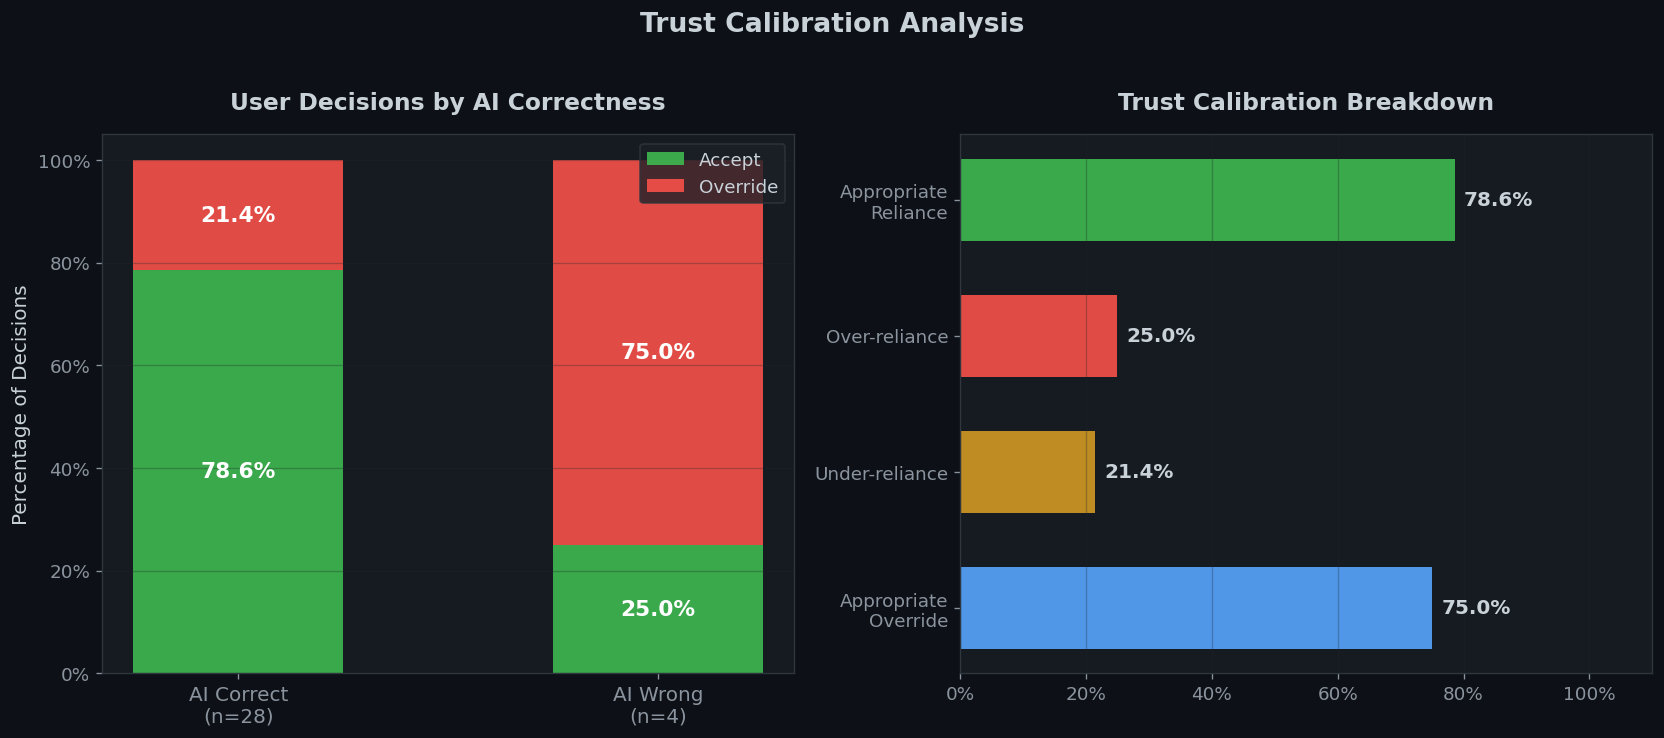

Trust Discrimination Ratio: 3.14
Verdict: WELL-CALIBRATED
Interpretation: Users appropriately distinguish correct from incorrect AI.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Stacked bar chart for AI Correct vs AI Wrong
ax = axes[0]
categories = ['AI Correct\n(n={})'.format(len(ai_correct)), 'AI Wrong\n(n={})'.format(len(ai_wrong))]
accept_vals = [
    (ai_correct['decision'] == 'Accept').sum() / len(ai_correct) * 100,
    (ai_wrong['decision'] == 'Accept').sum() / len(ai_wrong) * 100,
]
override_vals = [100 - v for v in accept_vals]

x = np.arange(len(categories))
bars1 = ax.bar(x, accept_vals, 0.5, label='Accept', color=COLORS['accept'], alpha=0.9, edgecolor='none')
bars2 = ax.bar(x, override_vals, 0.5, bottom=accept_vals, label='Override', color=COLORS['override'], alpha=0.9, edgecolor='none')

for bar, val in zip(bars1, accept_vals):
    if val > 8:
        ax.text(bar.get_x() + bar.get_width()/2, val/2, f'{val:.1f}%', ha='center', va='center', fontweight='bold', fontsize=13, color='white')
for bar, val, bot in zip(bars2, override_vals, accept_vals):
    if val > 8:
        ax.text(bar.get_x() + bar.get_width()/2, bot + val/2, f'{val:.1f}%', ha='center', va='center', fontweight='bold', fontsize=13, color='white')

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylabel('Percentage of Decisions', fontsize=12)
ax.set_title('User Decisions by AI Correctness', pad=15)
ax.legend(loc='upper right', framealpha=0.8, facecolor=COLORS['bg_card'], edgecolor='#30363d')
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis='y', alpha=0.3)

# ── Right: Trust Discrimination Gauge
ax2 = axes[1]
labels = ['Appropriate\nReliance', 'Over-reliance', 'Under-reliance', 'Appropriate\nOverride']
values = [appropriate_reliance, over_reliance, under_reliance, appropriate_override]
colors_bar = [COLORS['good'], COLORS['bad'], COLORS['warning'], COLORS['primary']]

bars = ax2.barh(labels, values, color=colors_bar, height=0.6, edgecolor='none', alpha=0.9)
for bar, val in zip(bars, values):
    ax2.text(val + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontweight='bold', fontsize=12, color='#c9d1d9')

ax2.set_xlim(0, 110)
ax2.set_title('Trust Calibration Breakdown', pad=15)
ax2.xaxis.set_major_formatter(mticker.PercentFormatter())
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

fig.suptitle('Trust Calibration Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Interpretation
if trust_discrimination > 1.5:
    verdict = 'WELL-CALIBRATED'
    emoji_verdict = 'Users appropriately distinguish correct from incorrect AI.'
elif trust_discrimination > 1.0:
    verdict = 'MODERATELY CALIBRATED'
    emoji_verdict = 'Users show some ability to distinguish AI correctness.'
else:
    verdict = 'POORLY CALIBRATED'
    emoji_verdict = 'Users fail to distinguish correct from incorrect AI.'

print(f'Trust Discrimination Ratio: {trust_discrimination:.2f}')
print(f'Verdict: {verdict}')
print(f'Interpretation: {emoji_verdict}')

---
## 4. Effect of Cue Dimensions on Trust

Each cue dimension is tested independently using chi-square tests for significance.
The key question: **Which interface cues influence user trust behavior?**

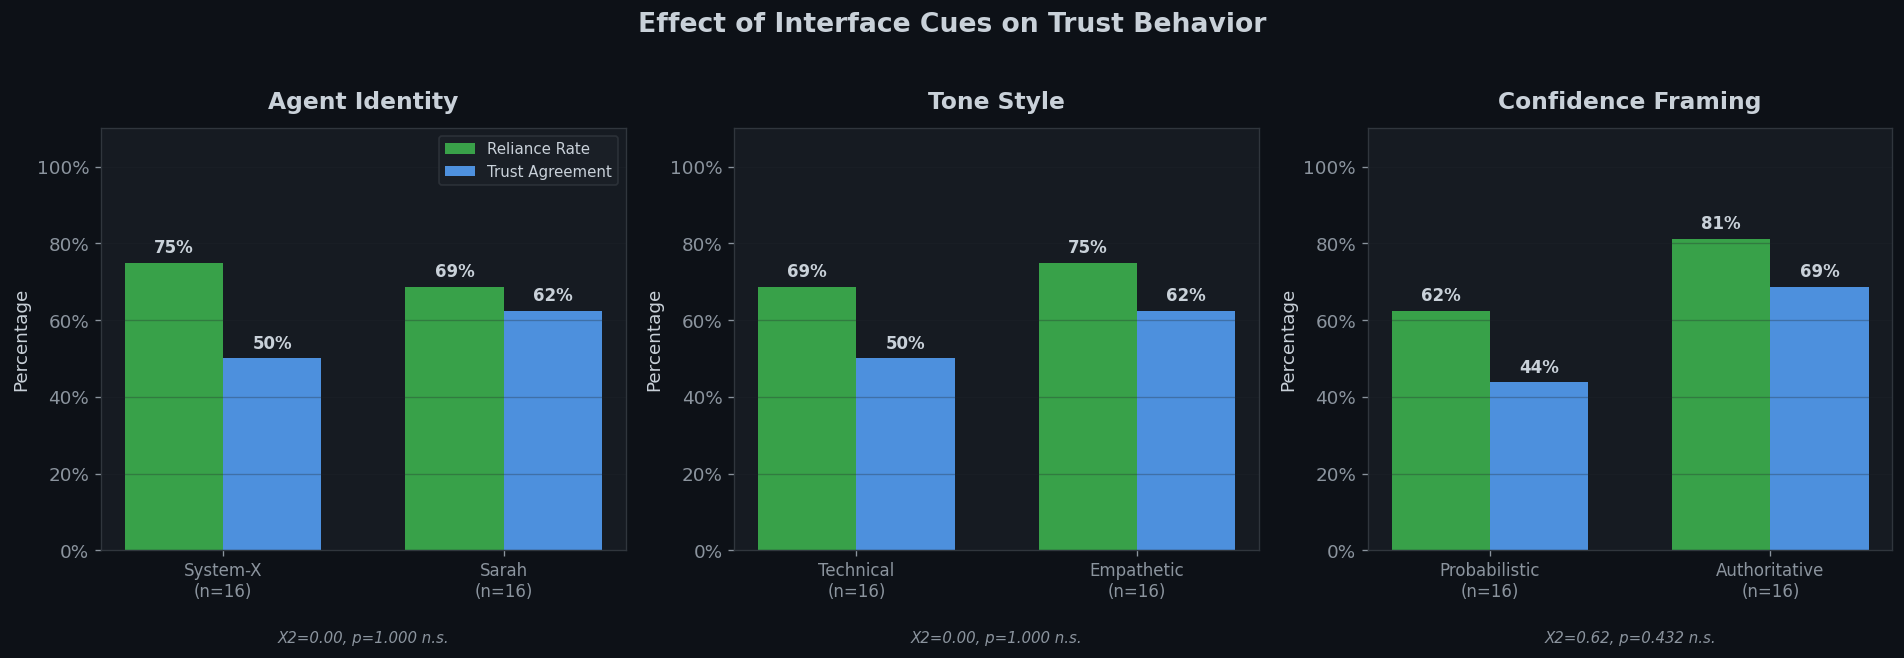

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

cue_dims = [
    ('agent_name', 'Agent Identity', ['System-X', 'Sarah']),
    ('tone_style', 'Tone Style', ['Technical', 'Empathetic']),
    ('confidence_framing', 'Confidence Framing', ['Probabilistic', 'Authoritative']),
]

for ax, (col, title, order) in zip(axes, cue_dims):
    # Compute reliance rate per group
    grouped = df.groupby(col).agg(
        reliance_rate=('decision', lambda x: (x == 'Accept').mean() * 100),
        trust_agreement=('user_agreed_with_ai', lambda x: x.mean() * 100),
        n=('decision', 'count')
    ).reindex(order)
    
    x = np.arange(len(order))
    w = 0.35
    b1 = ax.bar(x - w/2, grouped['reliance_rate'], w, label='Reliance Rate', color=COLORS['accept'], alpha=0.85, edgecolor='none')
    b2 = ax.bar(x + w/2, grouped['trust_agreement'], w, label='Trust Agreement', color=COLORS['primary'], alpha=0.85, edgecolor='none')
    
    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 1.5, f'{h:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#c9d1d9')
    
    ax.set_xticks(x)
    ax.set_xticklabels([f'{name}\n(n={int(grouped.loc[name, "n"])})' for name in order], fontsize=10)
    ax.set_ylabel('Percentage', fontsize=11)
    ax.set_title(title, pad=12)
    ax.set_ylim(0, 110)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.grid(axis='y', alpha=0.3)
    
    # Chi-square test
    ct = pd.crosstab(df[col], df['decision'])
    if ct.shape[0] >= 2 and ct.shape[1] >= 2:
        chi2, p, dof, _ = stats.chi2_contingency(ct)
        sig = '***' if p < 0.05 else 'n.s.'
        ax.text(0.5, -0.22, f'X2={chi2:.2f}, p={p:.3f} {sig}', transform=ax.transAxes, ha='center', fontsize=9, color=COLORS['muted'], style='italic')

axes[0].legend(loc='upper right', framealpha=0.8, facecolor=COLORS['bg_card'], edgecolor='#30363d', fontsize=9)
fig.suptitle('Effect of Interface Cues on Trust Behavior', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Over-reliance Analysis by Cue Dimension

Over-reliance is the **most concerning** trust failure — accepting AI advice when it's wrong.  
Which cues make users **more susceptible** to automation bias?

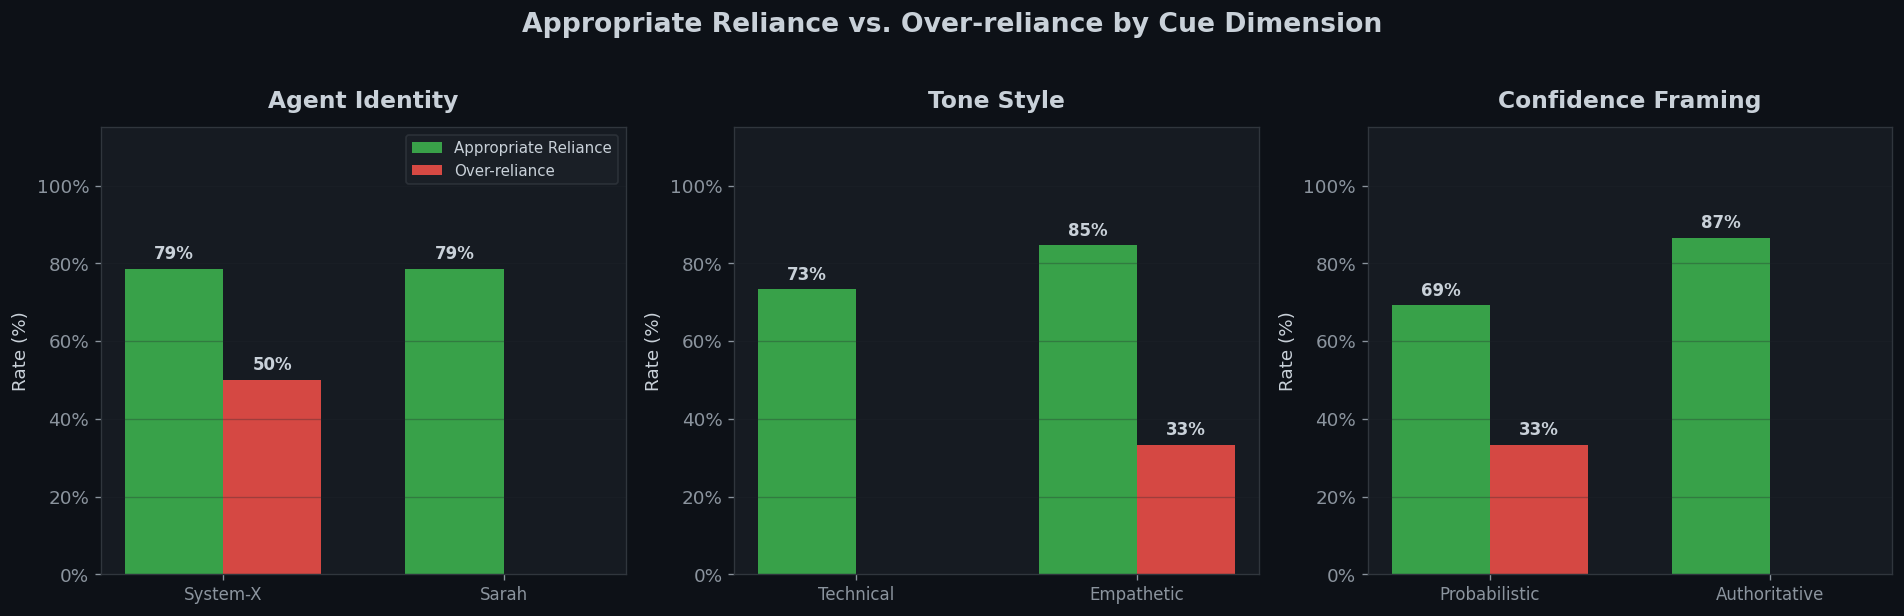

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, title, order) in zip(axes, cue_dims):
    over_rates = []
    appr_rates = []
    for name in order:
        subset = df[df[col] == name]
        wrong = subset[subset['ai_is_correct'] == False]
        correct = subset[subset['ai_is_correct'] == True]
        
        or_rate = (wrong['decision'] == 'Accept').sum() / len(wrong) * 100 if len(wrong) > 0 else 0
        ar_rate = (correct['decision'] == 'Accept').sum() / len(correct) * 100 if len(correct) > 0 else 0
        over_rates.append(or_rate)
        appr_rates.append(ar_rate)
    
    x = np.arange(len(order))
    w = 0.35
    b1 = ax.bar(x - w/2, appr_rates, w, label='Appropriate Reliance', color=COLORS['good'], alpha=0.85, edgecolor='none')
    b2 = ax.bar(x + w/2, over_rates, w, label='Over-reliance', color=COLORS['bad'], alpha=0.85, edgecolor='none')
    
    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width()/2, h + 1.5, f'{h:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#c9d1d9')
    
    ax.set_xticks(x)
    ax.set_xticklabels(order, fontsize=10)
    ax.set_ylabel('Rate (%)', fontsize=11)
    ax.set_title(title, pad=12)
    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.grid(axis='y', alpha=0.3)

axes[0].legend(loc='upper right', framealpha=0.8, facecolor=COLORS['bg_card'], edgecolor='#30363d', fontsize=9)
fig.suptitle('Appropriate Reliance vs. Over-reliance by Cue Dimension', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Response Latency Analysis

Latency reveals **deliberation patterns**:
- Do users take longer to override AI (suggesting cognitive conflict)?
- Do error scenarios cause longer deliberation?

Statistical significance tested with Welch's t-test.

/tmp/ipykernel_77692/330622917.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_77692/330622917.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot(
/tmp/ipykernel_77692/330622917.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = ax.boxplot(


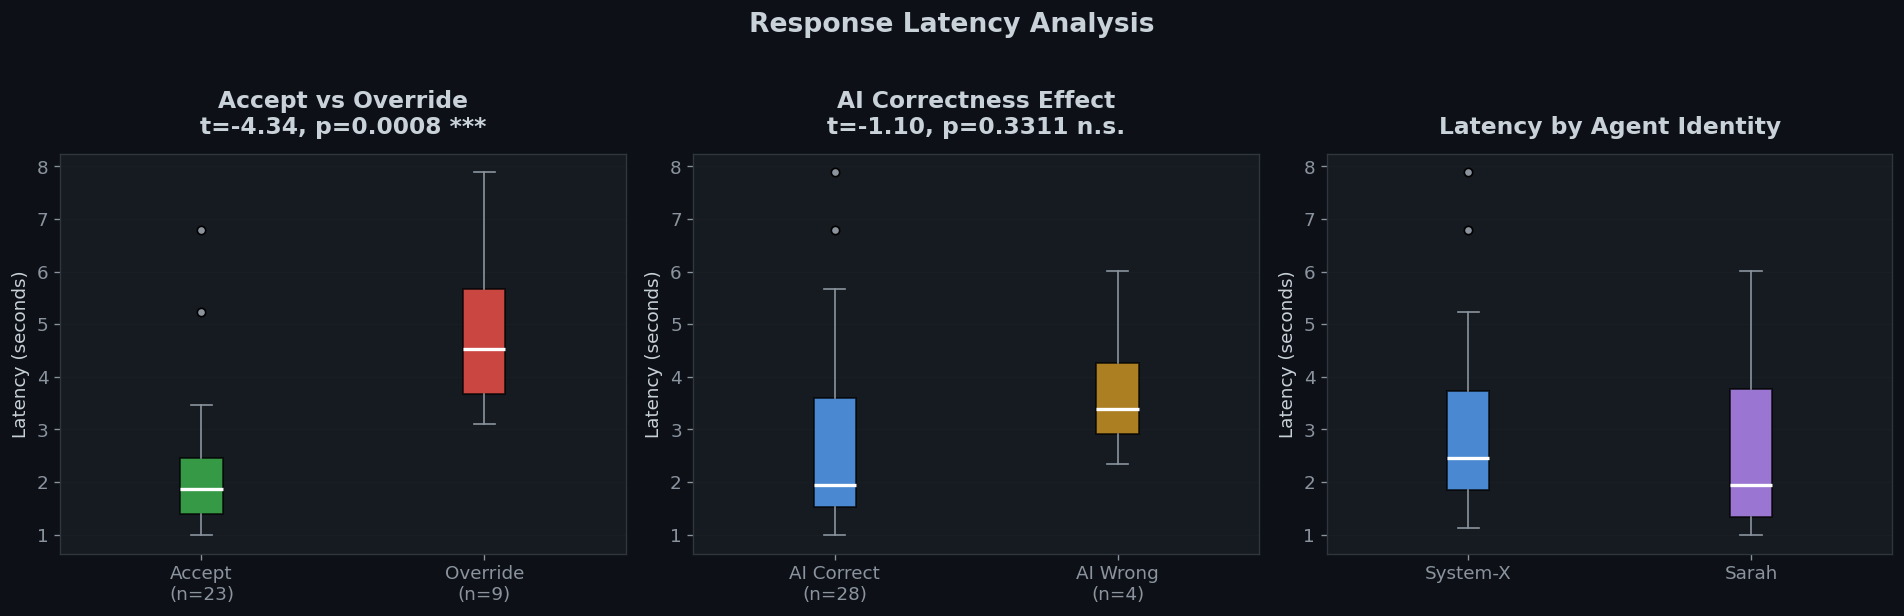

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: Accept vs Override latency
ax = axes[0]
accept_lat = df[df['decision'] == 'Accept']['latency_sec']
override_lat = df[df['decision'] == 'Override']['latency_sec']

bp = ax.boxplot(
    [accept_lat.values, override_lat.values],
    labels=[f'Accept\n(n={len(accept_lat)})', f'Override\n(n={len(override_lat)})'],
    patch_artist=True,
    boxprops=dict(alpha=0.8),
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color=COLORS['muted']),
    capprops=dict(color=COLORS['muted']),
    flierprops=dict(markerfacecolor=COLORS['muted'], markersize=5),
)
bp['boxes'][0].set_facecolor(COLORS['accept'])
bp['boxes'][1].set_facecolor(COLORS['override'])

t_stat, p_val = stats.ttest_ind(accept_lat, override_lat, equal_var=False)
sig = '***' if p_val < 0.05 else 'n.s.'
ax.set_title(f'Accept vs Override\nt={t_stat:.2f}, p={p_val:.4f} {sig}', pad=12)
ax.set_ylabel('Latency (seconds)', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# ── Plot 2: AI Correct vs AI Wrong latency
ax = axes[1]
correct_lat = df[df['ai_is_correct'] == True]['latency_sec']
wrong_lat = df[df['ai_is_correct'] == False]['latency_sec']

bp2 = ax.boxplot(
    [correct_lat.values, wrong_lat.values],
    labels=[f'AI Correct\n(n={len(correct_lat)})', f'AI Wrong\n(n={len(wrong_lat)})'],
    patch_artist=True,
    boxprops=dict(alpha=0.8),
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color=COLORS['muted']),
    capprops=dict(color=COLORS['muted']),
    flierprops=dict(markerfacecolor=COLORS['muted'], markersize=5),
)
bp2['boxes'][0].set_facecolor(COLORS['primary'])
bp2['boxes'][1].set_facecolor(COLORS['warning'])

if len(correct_lat) >= 2 and len(wrong_lat) >= 2:
    t2, p2 = stats.ttest_ind(correct_lat, wrong_lat, equal_var=False)
    sig2 = '***' if p2 < 0.05 else 'n.s.'
    ax.set_title(f'AI Correctness Effect\nt={t2:.2f}, p={p2:.4f} {sig2}', pad=12)
else:
    ax.set_title('AI Correctness Effect', pad=12)

ax.set_ylabel('Latency (seconds)', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# ── Plot 3: Latency by cue dimension (violin)
ax = axes[2]
cue_latency_data = []
cue_latency_labels = []
cue_latency_colors = []

for name in ['System-X', 'Sarah']:
    cue_latency_data.append(df[df['agent_name'] == name]['latency_sec'].values)
    cue_latency_labels.append(name)

bp3 = ax.boxplot(
    cue_latency_data,
    labels=cue_latency_labels,
    patch_artist=True,
    boxprops=dict(alpha=0.8),
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color=COLORS['muted']),
    capprops=dict(color=COLORS['muted']),
    flierprops=dict(markerfacecolor=COLORS['muted'], markersize=5),
)
bp3['boxes'][0].set_facecolor(COLORS['primary'])
bp3['boxes'][1].set_facecolor(COLORS['secondary'])
ax.set_title('Latency by Agent Identity', pad=12)
ax.set_ylabel('Latency (seconds)', fontsize=11)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('Response Latency Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Per-Condition Trust Profile

A heatmap of trust metrics across all 8 experimental conditions.  
Each row = one condition (unique combination of agent × tone × confidence).

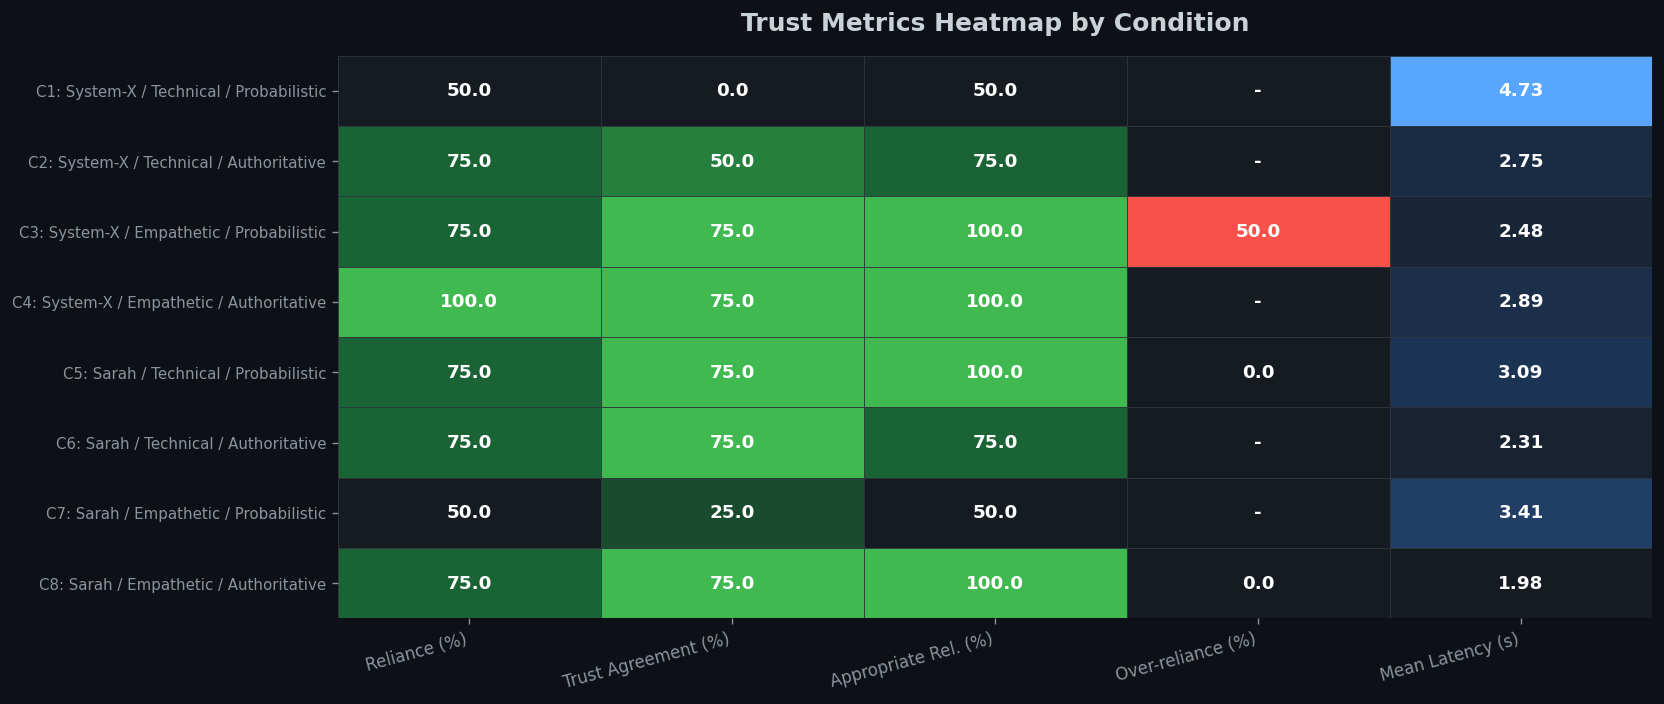


Condition Summary Table:
                                           Reliance (%)  Trust Agreement (%)  Mean Latency (s)  Appropriate Rel. (%)  Over-reliance (%)
Condition                                                                                                                              
C1: System-X / Technical / Probabilistic           50.0                  0.0              4.73                  50.0                NaN
C2: System-X / Technical / Authoritative           75.0                 50.0              2.75                  75.0                NaN
C3: System-X / Empathetic / Probabilistic          75.0                 75.0              2.48                 100.0               50.0
C4: System-X / Empathetic / Authoritative         100.0                 75.0              2.89                 100.0                NaN
C5: Sarah / Technical / Probabilistic              75.0                 75.0              3.09                 100.0                0.0
C6: Sarah / Technical 

In [8]:
# Compute per-condition metrics
condition_metrics = []
for cid, group in df.groupby('condition_id'):
    n = len(group)
    label = group['condition_label'].iloc[0]
    accepts = (group['decision'] == 'Accept').sum()
    
    row = {
        'Condition': f'C{cid}: {label}',
        'Reliance (%)': round(accepts / n * 100, 1),
        'Trust Agreement (%)': round(group['user_agreed_with_ai'].mean() * 100, 1),
        'Mean Latency (s)': round(group['latency_sec'].mean(), 2),
    }
    
    ai_c = group[group['ai_is_correct'] == True]
    ai_w = group[group['ai_is_correct'] == False]
    row['Appropriate Rel. (%)'] = round((ai_c['decision'] == 'Accept').sum() / len(ai_c) * 100, 1) if len(ai_c) > 0 else np.nan
    row['Over-reliance (%)'] = round((ai_w['decision'] == 'Accept').sum() / len(ai_w) * 100, 1) if len(ai_w) > 0 else np.nan
    
    condition_metrics.append(row)

cond_df = pd.DataFrame(condition_metrics).set_index('Condition')

fig, ax = plt.subplots(figsize=(14, 6))

# Heatmap
heatmap_data = cond_df[['Reliance (%)', 'Trust Agreement (%)', 'Appropriate Rel. (%)', 'Over-reliance (%)', 'Mean Latency (s)']].copy()

# Normalize for color mapping (each column 0-1)
norm_data = heatmap_data.copy()
for col in norm_data.columns:
    col_min = norm_data[col].min()
    col_max = norm_data[col].max()
    if col_max > col_min:
        norm_data[col] = (norm_data[col] - col_min) / (col_max - col_min)
    else:
        norm_data[col] = 0.5

# Custom colormap: dark -> teal -> green for good; invert for over-reliance
from matplotlib.colors import LinearSegmentedColormap
cmap_good = LinearSegmentedColormap.from_list('trust', ['#161b22', '#1a6334', '#3fb950'])
cmap_bad = LinearSegmentedColormap.from_list('risk', ['#161b22', '#8b3a3a', '#f85149'])
cmap_neutral = LinearSegmentedColormap.from_list('neutral', ['#161b22', '#1e3a5f', '#58a6ff'])

# Draw cell by cell
n_rows, n_cols = heatmap_data.shape
for i in range(n_rows):
    for j in range(n_cols):
        val = heatmap_data.iloc[i, j]
        norm_val = norm_data.iloc[i, j]
        
        if pd.isna(val):
            color = '#161b22'
            text = '-'
        else:
            col_name = heatmap_data.columns[j]
            if col_name == 'Over-reliance (%)':
                color = cmap_bad(norm_val)
            elif col_name == 'Mean Latency (s)':
                color = cmap_neutral(norm_val)
            else:
                color = cmap_good(norm_val)
            
            text = f'{val:.1f}' if col_name != 'Mean Latency (s)' else f'{val:.2f}'
        
        rect = plt.Rectangle((j, i), 1, 1, facecolor=color, edgecolor='#30363d', linewidth=0.5)
        ax.add_patch(rect)
        ax.text(j + 0.5, i + 0.5, text, ha='center', va='center', fontsize=11, fontweight='bold', color='white')

ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)
ax.set_xticks([j + 0.5 for j in range(n_cols)])
ax.set_xticklabels(heatmap_data.columns, fontsize=10, rotation=15, ha='right')
ax.set_yticks([i + 0.5 for i in range(n_rows)])
ax.set_yticklabels(heatmap_data.index, fontsize=9)
ax.invert_yaxis()
ax.set_title('Trust Metrics Heatmap by Condition', pad=15, fontsize=15)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

# Also print the raw table
print('\nCondition Summary Table:')
print(cond_df.to_string())

---
## 8. Decision Distribution Across Scenarios

How do decisions vary across the 10 business scenarios?  
Error scenarios (3, 5, 10) where AI gives deliberately wrong answers are highlighted.

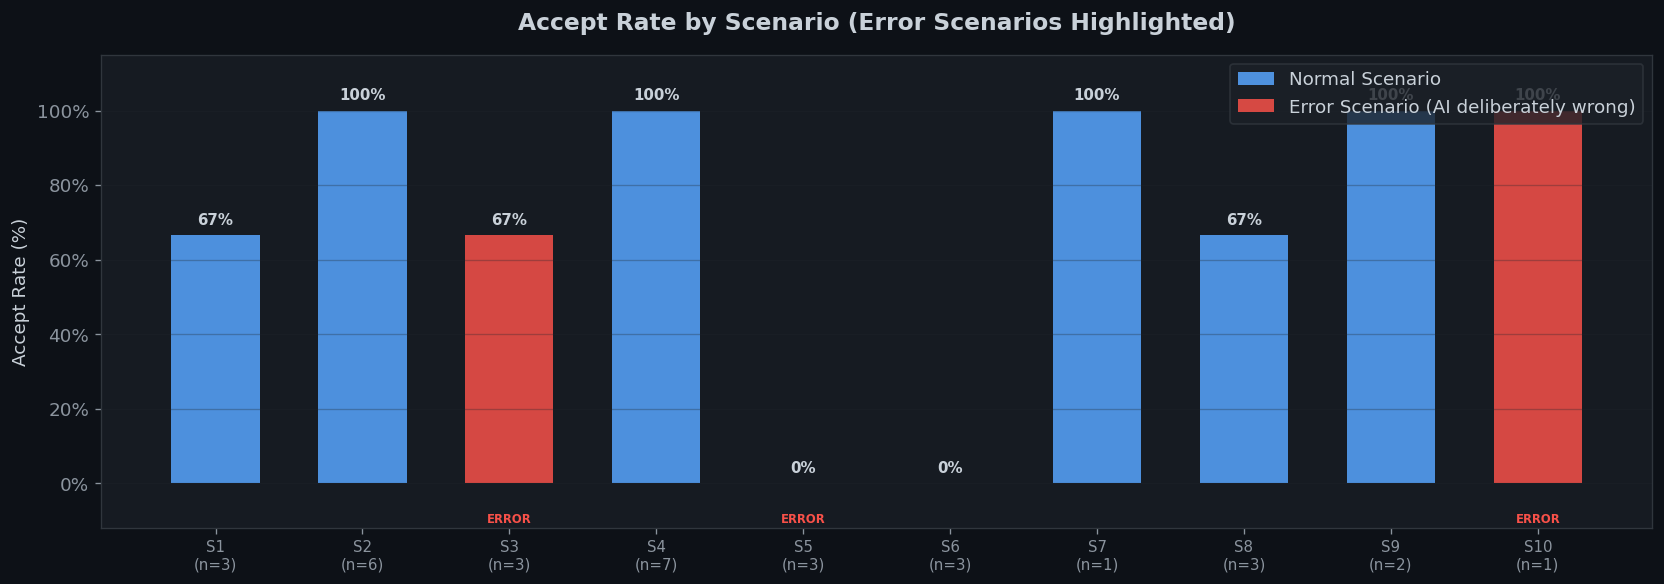

In [9]:
# Scenario-level analysis
scenario_data = df.groupby('scenario_id').agg(
    n=('decision', 'count'),
    accept_rate=('decision', lambda x: (x == 'Accept').mean() * 100),
    ai_correct=('ai_is_correct', 'mean'),
    correct_answer=('correct_answer', 'first'),
    mean_latency=('latency_sec', 'mean'),
).sort_index()

error_scenarios = [3, 5, 10]
scenario_data['is_error'] = scenario_data.index.isin(error_scenarios)

fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(scenario_data))
colors = [COLORS['bad'] if e else COLORS['primary'] for e in scenario_data['is_error']]
edge_colors = [COLORS['bad'] if e else COLORS['primary'] for e in scenario_data['is_error']]

bars = ax.bar(x, scenario_data['accept_rate'], color=colors, alpha=0.85, edgecolor='none', width=0.6)

for i, (bar, row) in enumerate(zip(bars, scenario_data.itertuples())):
    h = bar.get_height()
    label = f'{h:.0f}%'
    ax.text(bar.get_x() + bar.get_width()/2, h + 2, label, ha='center', va='bottom', fontsize=9, fontweight='bold', color='#c9d1d9')
    
    # Mark error scenarios
    if row.is_error:
        ax.text(bar.get_x() + bar.get_width()/2, -8, 'ERROR', ha='center', va='top', fontsize=7, fontweight='bold', color=COLORS['bad'])

ax.set_xticks(x)
ax.set_xticklabels([f'S{int(sid)}\n(n={int(scenario_data.loc[sid, "n"])})' for sid in scenario_data.index], fontsize=9)
ax.set_ylabel('Accept Rate (%)', fontsize=11)
ax.set_ylim(-12, 115)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis='y', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS['primary'], alpha=0.85, label='Normal Scenario'),
    Patch(facecolor=COLORS['bad'], alpha=0.85, label='Error Scenario (AI deliberately wrong)'),
]
ax.legend(handles=legend_elements, loc='upper right', framealpha=0.8, facecolor=COLORS['bg_card'], edgecolor='#30363d')

ax.set_title('Accept Rate by Scenario (Error Scenarios Highlighted)', pad=15)
plt.tight_layout()
plt.show()

---
## 9. Latency vs. Decision Scatter Plot

Each point is one trial. This reveals whether **deliberation time** varies  
based on the AI's correctness and the user's decision.

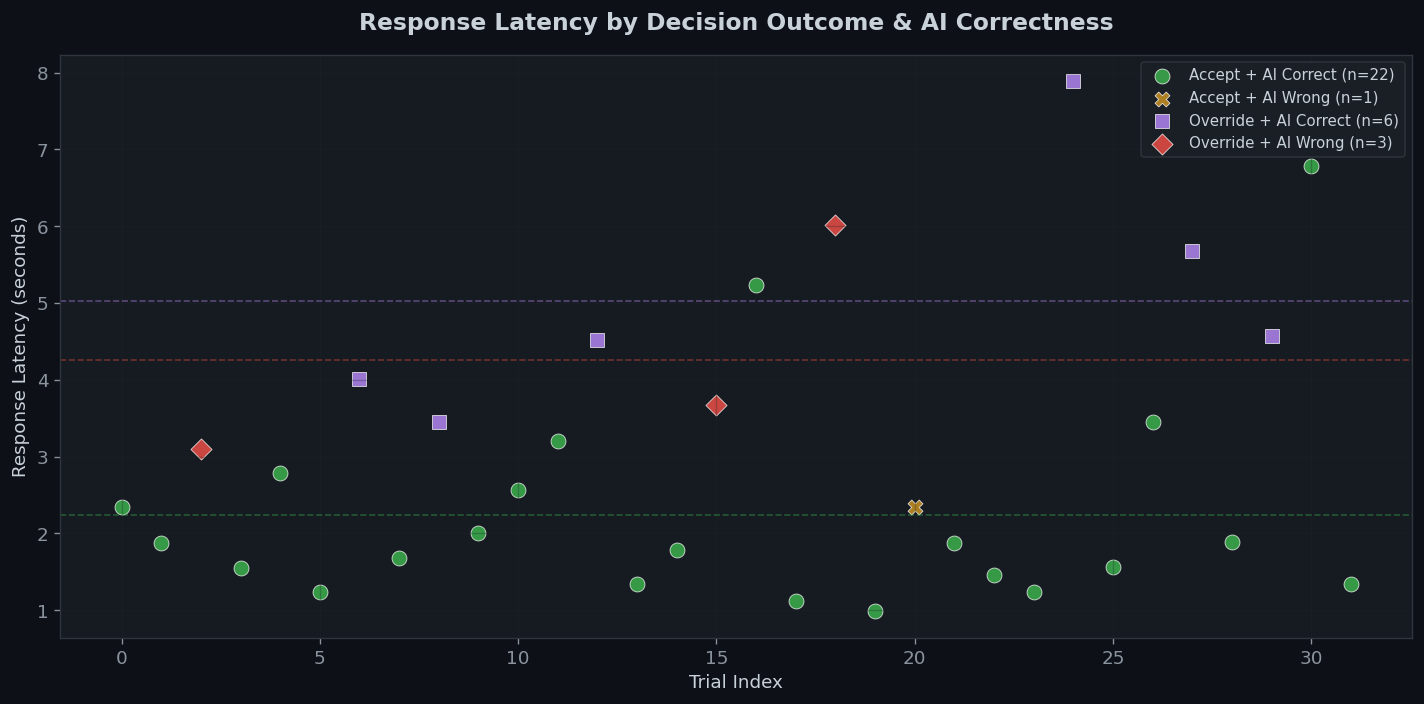

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

# Create 4 groups
groups = {
    'Accept + AI Correct': (df['decision'] == 'Accept') & (df['ai_is_correct'] == True),
    'Accept + AI Wrong': (df['decision'] == 'Accept') & (df['ai_is_correct'] == False),
    'Override + AI Correct': (df['decision'] == 'Override') & (df['ai_is_correct'] == True),
    'Override + AI Wrong': (df['decision'] == 'Override') & (df['ai_is_correct'] == False),
}

group_colors = {
    'Accept + AI Correct': COLORS['good'],
    'Accept + AI Wrong': COLORS['warning'],
    'Override + AI Correct': COLORS['secondary'],
    'Override + AI Wrong': COLORS['bad'],
}

group_markers = {
    'Accept + AI Correct': 'o',
    'Accept + AI Wrong': 'X',
    'Override + AI Correct': 's',
    'Override + AI Wrong': 'D',
}

for label, mask in groups.items():
    subset = df[mask]
    if len(subset) > 0:
        ax.scatter(
            subset.index, subset['latency_sec'],
            c=group_colors[label], marker=group_markers[label],
            s=80, alpha=0.8, edgecolors='white', linewidth=0.5,
            label=f'{label} (n={len(subset)})',
        )

ax.set_xlabel('Trial Index', fontsize=11)
ax.set_ylabel('Response Latency (seconds)', fontsize=11)
ax.set_title('Response Latency by Decision Outcome & AI Correctness', pad=15)
ax.legend(loc='upper right', framealpha=0.8, facecolor=COLORS['bg_card'], edgecolor='#30363d', fontsize=9)
ax.grid(alpha=0.3)

# Mean lines
for label, mask in groups.items():
    subset = df[mask]
    if len(subset) > 1:
        ax.axhline(y=subset['latency_sec'].mean(), color=group_colors[label], linestyle='--', alpha=0.4, linewidth=1)

plt.tight_layout()
plt.show()

---
## 10. Statistical Summary

Formal statistical tests to determine the significance of observed patterns.

In [11]:
print('=' * 65)
print('  STATISTICAL SUMMARY')
print('=' * 65)

# Test 1: Accept vs Override latency
print('\n1. ACCEPT vs OVERRIDE LATENCY (Welch\'s t-test)')
t, p = stats.ttest_ind(accept_lat, override_lat, equal_var=False)
print(f'   Accept mean:   {accept_lat.mean():.1f}s  (n={len(accept_lat)})')
print(f'   Override mean: {override_lat.mean():.1f}s  (n={len(override_lat)})')
print(f'   t = {t:.3f}, p = {p:.4f} {"***" if p < 0.05 else "(n.s.)"}')

# Test 2: AI Correct vs Wrong latency
print('\n2. AI CORRECT vs AI WRONG LATENCY (Welch\'s t-test)')
if len(correct_lat) >= 2 and len(wrong_lat) >= 2:
    t2, p2 = stats.ttest_ind(correct_lat, wrong_lat, equal_var=False)
    print(f'   Correct mean: {correct_lat.mean():.1f}s  (n={len(correct_lat)})')
    print(f'   Wrong mean:   {wrong_lat.mean():.1f}s  (n={len(wrong_lat)})')
    print(f'   t = {t2:.3f}, p = {p2:.4f} {"***" if p2 < 0.05 else "(n.s.)"}')

# Test 3-5: Chi-square for each cue dimension
for i, (col, title, _) in enumerate(cue_dims, 3):
    print(f'\n{i}. {title.upper()} x DECISION (Chi-square test)')
    ct = pd.crosstab(df[col], df['decision'])
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    print(f'   X2 = {chi2:.3f}, df = {dof}, p = {p:.4f} {"***" if p < 0.05 else "(n.s.)"}')
    print(f'   Observed:\n{ct.to_string()}')

print(f'\n{"=" * 65}')
print(f'\nNote: *** = significant at p < 0.05; n.s. = not significant')
print(f'Sample size: {len(df)} records. Larger samples needed for robust conclusions.')

  STATISTICAL SUMMARY

1. ACCEPT vs OVERRIDE LATENCY (Welch's t-test)
   Accept mean:   2.2s  (n=23)
   Override mean: 4.8s  (n=9)
   t = -4.335, p = 0.0008 ***

2. AI CORRECT vs AI WRONG LATENCY (Welch's t-test)
   Correct mean: 2.8s  (n=28)
   Wrong mean:   3.8s  (n=4)
   t = -1.097, p = 0.3311 (n.s.)

3. AGENT IDENTITY x DECISION (Chi-square test)
   X2 = 0.000, df = 1, p = 1.0000 (n.s.)
   Observed:
decision    Accept  Override
agent_name                  
Sarah           11         5
System-X        12         4

4. TONE STYLE x DECISION (Chi-square test)
   X2 = 0.000, df = 1, p = 1.0000 (n.s.)
   Observed:
decision    Accept  Override
tone_style                  
Empathetic      12         4
Technical       11         5

5. CONFIDENCE FRAMING x DECISION (Chi-square test)
   X2 = 0.618, df = 1, p = 0.4317 (n.s.)
   Observed:
decision            Accept  Override
confidence_framing                  
Authoritative           13         3
Probabilistic           10         6


Note: *

---
## 11. Key Findings & Interpretation

Based on the analysis above:

In [12]:
print('KEY FINDINGS')
print('=' * 65)

# Finding 1
if trust_discrimination > 1.5:
    print(f'\n1. TRUST CALIBRATION: GOOD')
    print(f'   Users accept AI {appropriate_reliance:.1f}% of the time when correct,')
    print(f'   but only {over_reliance:.1f}% when wrong (ratio: {trust_discrimination:.2f})')
elif trust_discrimination > 1.0:
    print(f'\n1. TRUST CALIBRATION: MODERATE')
    print(f'   Some ability to distinguish correct/incorrect AI.')
else:
    print(f'\n1. TRUST CALIBRATION: POOR')
    print(f'   Users cannot reliably detect incorrect AI recommendations.')

# Finding 2: Latency
if p_val < 0.05:
    faster, slower = ('Accept', 'Override') if accept_lat.mean() < override_lat.mean() else ('Override', 'Accept')
    print(f'\n2. DELIBERATION PATTERN: SIGNIFICANT')
    print(f'   {slower} decisions take significantly longer (p={p_val:.4f}),')
    print(f'   suggesting users deliberate more when { "disagreeing with" if slower == "Override" else "agreeing with"} AI.')
else:
    print(f'\n2. DELIBERATION PATTERN: NOT SIGNIFICANT')
    print(f'   No reliable latency difference between Accept and Override.')

# Finding 3: Cue effects
sig_cues = []
for col, title, _ in cue_dims:
    ct = pd.crosstab(df[col], df['decision'])
    _, p_chi, _, _ = stats.chi2_contingency(ct)
    if p_chi < 0.05:
        sig_cues.append(title)

if sig_cues:
    print(f'\n3. CUE EFFECTS: {", ".join(sig_cues)} significantly influence trust.')
else:
    print(f'\n3. CUE EFFECTS: No significant effects detected (p > 0.05).')
    print(f'   This may be due to small sample size (n={len(df)}).')
    print(f'   A minimum of ~30 responses per condition is recommended.')

# Finding 4: User accuracy
print(f'\n4. USER ACCURACY: {user_accuracy:.1f}%')
if user_accuracy >= 70:
    print(f'   Human + AI collaboration is effective at reaching correct decisions.')
else:
    print(f'   Below 70% — may indicate over-reliance on incorrect AI or poor judgment.')

print(f'\n{"=" * 65}')

KEY FINDINGS

1. TRUST CALIBRATION: GOOD
   Users accept AI 78.6% of the time when correct,
   but only 25.0% when wrong (ratio: 3.14)

2. DELIBERATION PATTERN: SIGNIFICANT
   Override decisions take significantly longer (p=0.0008),
   suggesting users deliberate more when disagreeing with AI.

3. CUE EFFECTS: No significant effects detected (p > 0.05).
   This may be due to small sample size (n=32).
   A minimum of ~30 responses per condition is recommended.

4. USER ACCURACY: 53.1%
   Below 70% — may indicate over-reliance on incorrect AI or poor judgment.



---

*Analysis generated by the Human-AI Trust Experimentation Engine.*  
*GSoC 2026 — Humanlike AI Systems and Trust Attribution — ISSR / University of Alabama*